# Full spectrum example

This notebook compares the output of Eradiate's Mitsuba and DISORT backends for spectral computations.

In [1]:
# Documentation-specific setup, hidden from notebook output

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import seaborn as sns

sns.set_theme(style="ticks")

In [2]:
import eradiate
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from eradiate.experiments import AtmosphereExperiment
from eradiate.units import unit_registry as ureg

import eradiate_disort as ed

eradiate.set_mode("ckd")

In [3]:
# Constants
ABSORPTION_DB = (
    "monotropa"  # change to 'panellus' (1 nm resolution) or 'mycena' (10 nm)
)

In [4]:
from eradiate_disort.testing import TestMode

# Overwrite ABSORPTION_DB according to detected test mode
if TestMode.get() == "test":
    ABSORPTION_DB = "mycena"  # fast mode in regression tests
else:
    ABSORPTION_DB = "monotropa"

## Surface spectrum loading

In [5]:
# Load surface spectrum
from eradiate.scenes.spectra import InterpolatedSpectrum

albedo_data = np.loadtxt(
    eradiate.fresolver.resolve("spectra/HAMSTER_spectral_albedo_Gobabeb_015.txt"),
    skiprows=1,
)
albedo_spectrum = InterpolatedSpectrum(
    wavelengths=albedo_data[:, 0], values=albedo_data[:, 1]
)

## Experiment definition

In [6]:
def experiment(backend, wmin=600.0, wmax=610.0, tau_ref=0.0):
    srf = {"type": "uniform", "wmin": wmin, "wmax": wmax}
    angles = {"construct": "hplane", "azimuth": 75.0, "zeniths": [60.0]}
    measures = (
        [
            {
                "id": "radiance_toa",
                "type": "mdistant",
                **angles,
                "srf": srf,
            },
            {
                "id": "radiance_boa",
                "type": "mdistant",
                **angles,
                "srf": srf,
                "target": [1, 1, 0],
            },
        ]  # Mitsuba backend: 2 measurements (TOA and BOA levels)
        if backend == "mitsuba"
        else {"id": "disort", "type": "disort", **angles, "srf": srf}
        # DISORT backend: single measurement to record both TOA and BOA (default)
    )

    particle_layer = (
        {
            "tau_ref": tau_ref,
            "w_ref": 550.0,
            "bottom": 0.0,
            "top": 3.0 * ureg.km,
            "distribution": "uniform",
            # "dataset": "soot.mie-aer_core_v2",
            "dataset": "wc.sol.mie_reff.010-aer_core_v2",
        }
        if tau_ref
        else []
    )  # Cloud particle layer if tau_ref is nonzero

    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 120.0 * ureg.km,
            "zgrid": np.linspace(0, 120, 121) * ureg.km,
        },
        surface={"type": "lambertian", "reflectance": albedo_spectrum},
        atmosphere={
            "type": "heterogeneous",
            "molecular_atmosphere": {"absorption_data": ABSORPTION_DB},
            "particle_layers": particle_layer,
        },
        illumination={
            "type": "directional",
            "zenith": 30.0,
            "azimuth": 160.0,
        },
        measures=measures,
    )
    exp.integrator.moment = True

    return exp

## Processing

In [7]:
exp_kwargs = {"wmin": 600.0, "wmax": 650.0, "tau_ref": 0.0}
# exp_kwargs = {"wmin": 600.0, "wmax": 850.0, "tau_ref": 0.0}
# exp_kwargs = {"wmin": 600.0, "wmax": 850.0, "tau_ref": 10.0}
# exp_kwargs = {"wmin": 600.0, "wmax": 650.0, "tau_ref": 10.0}

exp_mitsuba = experiment("mitsuba", **exp_kwargs)
eradiate.run(exp_mitsuba, spp=10_000)
result_mitsuba = exp_mitsuba.results

exp_disort = experiment("disort", **exp_kwargs)
backend = ed.DisortBackend()
result_disort = backend.run(exp_disort)

0/224|          | 00:00, ETA=?

0/224|          | 00:00, ETA=?

## TOA radiance and BRF plotting

In [8]:
# Extract irradiance
irradiance_toa_mitsuba = result_mitsuba["radiance_toa"]["irradiance"].squeeze()

# Extract Mitsuba radiance
radiance_toa_mitsuba = result_mitsuba["radiance_toa"]["radiance"].squeeze()
radiance_toa_mitsuba_std = np.sqrt(
    result_mitsuba["radiance_toa"]["radiance_var"].squeeze()
)

# Compute Mitsuba BRF standard deviation
brf_toa_mitsuba = result_mitsuba["radiance_toa"]["brf"].squeeze()
x = np.pi / result_mitsuba["radiance_toa"]["irradiance"]
brf_toa_mitsuba_std = np.sqrt(
    (result_mitsuba["radiance_toa"]["radiance_var"] * x**2).squeeze()
)

# Compute DISORT BRF
radiance_toa_disort = result_disort["disort"]["uu"].isel(z=0).squeeze()
irradiance_toa_disort = result_disort["disort"]["rfldir"].isel(z=0).squeeze()
cos_theta_s = np.cos(exp_disort.illumination.zenith.m_as("rad"))
brf_toa_disort = radiance_toa_disort / irradiance_toa_disort * np.pi

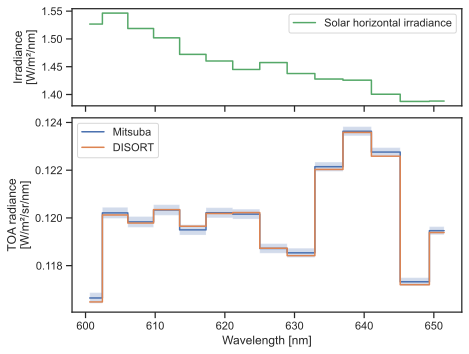

In [9]:
wmin, wmax = 600.0, 850.0
# wmin, wmax = 600.0, 610.0
# wmin, wmax = 750.0, 780.0

fig, axs = plt.subplots(2, 1, height_ratios=[0.5, 1], sharex=True, layout="constrained")

ax = axs[0]
x = irradiance_toa_mitsuba["w"].values
y = irradiance_toa_mitsuba.values

mask = (x >= wmin) & (x <= wmax)
ax.step(x[mask], y[mask], where="mid", label="Solar horizontal irradiance", c="C2")

ax.set_ylabel("Irradiance\n[W/m²/nm]")
ax.legend()

ax = axs[1]
x = radiance_toa_mitsuba["w"].values
y = radiance_toa_mitsuba.values
y_std = radiance_toa_mitsuba_std.values
ymin = y - y_std * 2.0
ymax = y + y_std * 2.0

mask = (x >= wmin) & (x <= wmax)
ax.step(x[mask], y[mask], where="mid", label="Mitsuba")
ax.fill_between(x[mask], ymin[mask], ymax[mask], step="mid", alpha=0.25)

x = radiance_toa_disort["w"].values
y = radiance_toa_disort.values

mask = (x >= wmin) & (x <= wmax)
ax.step(x[mask], y[mask], where="mid", label="DISORT")

ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("TOA radiance\n[W/m²/sr/nm]")
# ax.set_ylim(-0.01, 0.51)
ax.legend()

plt.show()
plt.close()

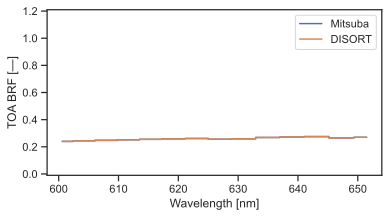

In [10]:
# wmin, wmax = 650.0, 850.0
# wmin, wmax = 750.0, 780.0
# wmin, wmax = 660.0, 680.0

fig, ax = plt.subplots(1, 1, figsize=(6, 3))

x = brf_toa_mitsuba["w"].values
y = brf_toa_mitsuba.values
y_std = brf_toa_mitsuba_std.values
ymin = y - y_std * 2.0
ymax = y + y_std * 2.0
mask = (x >= wmin) & (x <= wmax)
ax.step(x[mask], y[mask], where="mid", label="Mitsuba")
ax.fill_between(x[mask], ymin[mask], ymax[mask], step="mid", alpha=0.25)

x = brf_toa_disort["w"].values
y = brf_toa_disort.values
mask = (x >= wmin) & (x <= wmax)
ax.step(x[mask], y[mask], where="mid", label="DISORT")

# x = albedo_spectrum.wavelengths.m_as("nm")
# y = albedo_spectrum.values
# mask = (x >= wmin) & (x <= wmax)
# ax.plot(x[mask], y[mask], label="Surface", c="gray", zorder=1, ls="--")

ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("TOA BRF [—]")
ax.set_ylim(-0.01, 1.21)
ax.legend()

plt.show()
plt.close()

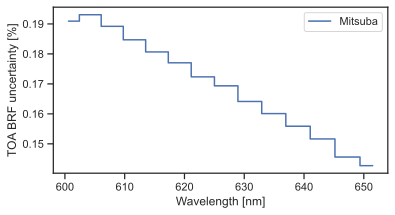

In [11]:
# wmin, wmax = 650.0, 850.0
# wmin, wmax = 750.0, 780.0
# wmin, wmax = 660.0, 680.0

fig, ax = plt.subplots(1, 1, figsize=(6, 3))

x = brf_toa_mitsuba["w"].values
brf = brf_toa_mitsuba.values
brf_std = brf_toa_mitsuba_std.values
y = brf_std / brf * 2.0 * 100.0
mask = (x >= wmin) & (x <= wmax)
ax.step(x[mask], y[mask], where="mid", label="Mitsuba")

ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("TOA BRF uncertainty [%]")
# ax.set_ylim(-1, None)
ax.legend()

plt.show()
plt.close()

## BOA radiance plotting

In [12]:
# Extract irradiance
irradiance_toa_mitsuba = result_mitsuba["radiance_toa"]["irradiance"].squeeze()

# Extract Mitsuba radiance
radiance_boa_mitsuba = result_mitsuba["radiance_toa"]["radiance"].squeeze()
radiance_boa_mitsuba_std = np.sqrt(
    result_mitsuba["radiance_toa"]["radiance_var"].squeeze()
)

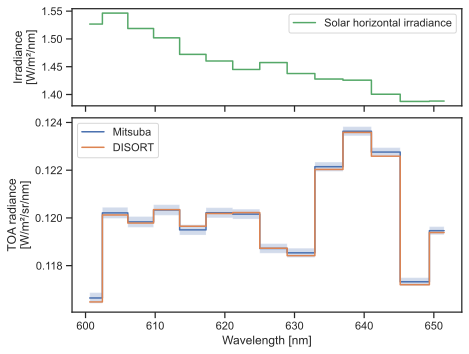

In [13]:
wmin, wmax = 600.0, 850.0
# wmin, wmax = 600.0, 610.0
# wmin, wmax = 750.0, 780.0

fig, axs = plt.subplots(2, 1, height_ratios=[0.5, 1], sharex=True, layout="constrained")

ax = axs[0]
x = irradiance_toa_mitsuba["w"].values
y = irradiance_toa_mitsuba.values

mask = (x >= wmin) & (x <= wmax)
ax.step(x[mask], y[mask], where="mid", label="Solar horizontal irradiance", c="C2")

ax.set_ylabel("Irradiance\n[W/m²/nm]")
ax.legend()

ax = axs[1]
x = radiance_boa_mitsuba["w"].values
y = radiance_boa_mitsuba.values
y_std = radiance_boa_mitsuba_std.values
ymin = y - y_std * 2.0
ymax = y + y_std * 2.0

mask = (x >= wmin) & (x <= wmax)
ax.step(x[mask], y[mask], where="mid", label="Mitsuba")
ax.fill_between(x[mask], ymin[mask], ymax[mask], step="mid", alpha=0.25)

x = radiance_toa_disort["w"].values
y = radiance_toa_disort.values

mask = (x >= wmin) & (x <= wmax)
ax.step(x[mask], y[mask], where="mid", label="DISORT")

ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("TOA radiance\n[W/m²/sr/nm]")
# ax.set_ylim(-0.01, 0.51)
ax.legend()

plt.show()
plt.close()